In [6]:
import pandas as pd
import seaborn as sns

In [7]:
lupe_data_raw = pd.read_csv("data/twitterIceResults.csv")

In [ ]:
lupe_data_raw.head()

,Query,View Count,Repost,Likes,Trauma Porn,Key Words,LINK,Notes on Rhetoric
0,"""ICE""",22M,25k,138k,"Yes. Video has a ""Content Warning: Graphic Con...","""Almost killed"", ""appears to have been dragge...",https://x.com/elonmusk/status/2009292194406895...,Painting ICE agent as someone objectively doin...
1,"""ICE""",37k,17k,289,Yes.,"""shoved by ICE agent""",https://x.com/TRIGGERHAPPYV1/status/1982809792...,NaN
2,"""ICE""",251k,540,8.8k,No.,"""rage bait by...ICE agent""",NaN,Belitting connotation
3,"""ICE""",11k,230,717,No.,"""foreign fugitive"" ""HOMICIDE"" ""SEXUAL ASSAULT""...",https://x.com/ICEgov/status/204802446195004670...,from U.S. ICE twitter account
4,"""ICE""",27k,10,147,No.,"""Unmasked"" ""spotted running"" ""deployed"" ""crisis""",https://x.com/TRIGGERHAPPYV1/status/2036237672...,Victim ICE


In [10]:
def num_yes(col):
    return sum(col.str.startswith("Yes"))

bar_data = lupe_data_raw.groupby("Query")["Trauma Porn"].agg(lambda col : num_yes(col)/ len(col))

In [11]:
bar_data

Query
"ICE Activity"       0.615385
"ICE Fresno"         0.000000
"ICE Long Beach"     0.476190
"ICE Minneapolis"    0.523810
"ICE New York"       0.142857
"ICE Spottings"      0.142857
"ICE"                0.300000
Name: Trauma Porn, dtype: float64

C:\Users\zdzhn\AppData\Local\Temp\ipykernel_21540\219716189.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bar_data.index, y=bar_data, ax=ax, palette="Blues_d")
C:\Users\zdzhn\AppData\Local\Temp\ipykernel_21540\219716189.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)


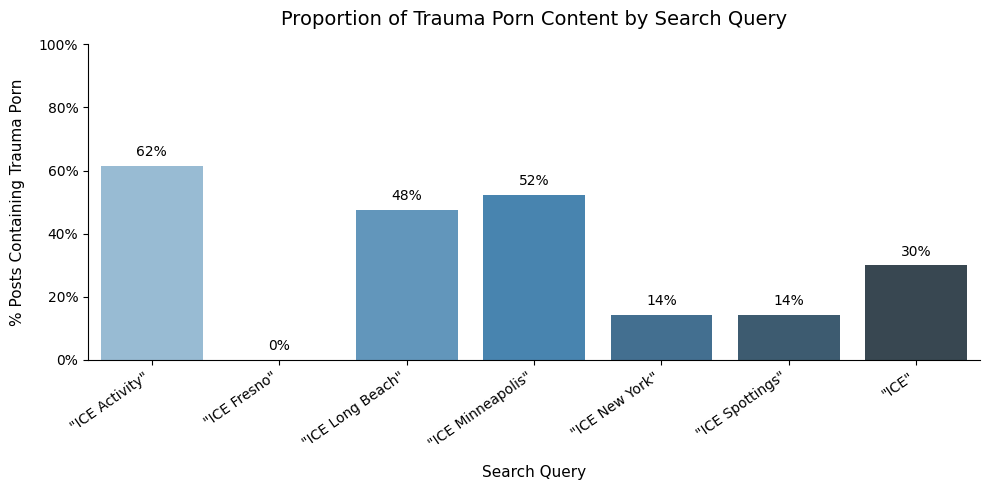

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(x=bar_data.index, y=bar_data, ax=ax, palette="Blues_d")

ax.set_title("Proportion of Trauma Porn Content by Search Query", fontsize=14, pad=14)
ax.set_xlabel("Search Query", fontsize=11, labelpad=10)
ax.set_ylabel("% Posts Containing Trauma Porn", fontsize=11, labelpad=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
ax.set_ylim(0, 1)
sns.despine()

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.0%}",
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.show()

In [13]:
fig.savefig("../static/images/trauma_porn_bar.png", dpi=150, bbox_inches="tight")